# Práctica 2 — Parte 2: Serie temporal AAPL (RNN y LSTM)


## Dependencias

Los archivos `AAPL.xls` y `AAPL - Jan2018.xls` son CSV con extensión `.xls`; se leen con `read_csv`.


In [1]:
import subprocess
import sys

PIP_DEPS = [
    "numpy>=1.24",
    "pandas>=2.0",
    "matplotlib>=3.7",
    "scikit-learn>=1.3",
    "tensorflow>=2.15",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", *PIP_DEPS])
print("Instalado con:", sys.executable)


Instalado con: d:\Code, 3D, Audio\Coding\GitHub\UNAL-ML\.venv\Scripts\python.exe


## 1. Configuración


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

for _style in ("seaborn-v0_8-whitegrid", "seaborn-whitegrid", "ggplot"):
    try:
        plt.style.use(_style)
        break
    except OSError:
        continue

def _find_root(rel: str) -> Path:
    c = Path.cwd()
    for base in (c, c.parent, c.parent.parent):
        if (base / rel).exists():
            return base
    return c.parent


ROOT = _find_root("datos/AAPL.xls")
TRAIN_PATH = ROOT / "datos" / "AAPL.xls"
EVAL_PATH = ROOT / "datos" / "AAPL - Jan2018.xls"
print("Train:", TRAIN_PATH.resolve())
print("Eval:", EVAL_PATH.resolve())


Train: D:\Code, 3D, Audio\Coding\GitHub\UNAL-ML\practica_2\datos\AAPL.xls
Eval: D:\Code, 3D, Audio\Coding\GitHub\UNAL-ML\practica_2\datos\AAPL - Jan2018.xls


## 2. Carga y preparación

Objetivo: predecir el **Open** del día siguiente usando una ventana de `LOOKBACK` días. El modelo se entrena con todo el histórico del archivo de entrenamiento; la evaluación usa enero 2018 concatenando al inicio la cola de 2017 para construir la primera ventana.


In [3]:
def load_series(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, parse_dates=["Date"], dayfirst=False)
    df = df.sort_values("Date").reset_index(drop=True)
    return df


train_df = load_series(TRAIN_PATH)
eval_df = load_series(EVAL_PATH)

LOOKBACK = 30

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df[["Open"]].astype(np.float32))


def make_xy(series_scaled: np.ndarray):
    X, y = [], []
    for i in range(LOOKBACK, len(series_scaled)):
        X.append(series_scaled[i - LOOKBACK : i, 0])
        y.append(series_scaled[i, 0])
    return np.asarray(X, dtype=np.float32)[..., np.newaxis], np.asarray(y, dtype=np.float32)


X_train, y_train = make_xy(train_scaled)
print("Secuencias entrenamiento:", X_train.shape, y_train.shape)

# Evaluación: últimos LOOKBACK opens del train (escalados) + serie eval
tail = train_scaled[-LOOKBACK:, 0]
eval_scaled = scaler.transform(eval_df[["Open"]].astype(np.float32))[:, 0]
combined = np.concatenate([tail, eval_scaled], axis=0)

X_eval, y_eval = [], []
# predicciones alineadas a cada día de eval_df: target es el open del día siguiente dentro de combined
for j in range(len(eval_scaled)):
    start = j
    end = j + LOOKBACK
    if end >= len(combined):
        break
    X_eval.append(combined[start:end])
    y_eval.append(combined[end])

X_eval = np.asarray(X_eval, dtype=np.float32)[..., np.newaxis]
y_eval = np.asarray(y_eval, dtype=np.float32)
print("Secuencias eval (enero 2018):", X_eval.shape, y_eval.shape)


Secuencias entrenamiento: (1229, 30, 1) (1229,)
Secuencias eval (enero 2018): (20, 30, 1) (20,)


## 3. Modelo RNN (apilada)


In [4]:
def build_rnn():
    return keras.Sequential(
        [
            layers.Input(shape=(LOOKBACK, 1)),
            layers.SimpleRNN(64, return_sequences=True),
            layers.SimpleRNN(32, return_sequences=False),
            layers.Dense(1),
        ],
        name="StackedRNN",
    )


def metrics_report(y_true, y_pred, name: str):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)
    print(f"{name}: MAE={mae:.6f}  RMSE={rmse:.6f}  R2={r2:.4f}")


rnn = build_rnn()
rnn.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", jit_compile=False)

cb = keras.callbacks.EarlyStopping(monitor="loss", patience=8, restore_best_weights=True)
hist_rnn = rnn.fit(X_train, y_train, epochs=80, batch_size=32, verbose=1, callbacks=[cb])

y_tr_rnn = rnn.predict(X_train, verbose=0).ravel()
y_ev_rnn = rnn.predict(X_eval, verbose=0).ravel()
metrics_report(y_train, y_tr_rnn, "RNN train (scaled)")
metrics_report(y_eval, y_ev_rnn, "RNN eval enero 2018 (scaled)")


Epoch 1/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0218
Epoch 2/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0010 
Epoch 3/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.2450e-04
Epoch 4/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.5076e-04
Epoch 5/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.2200e-04
Epoch 6/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.9568e-04
Epoch 7/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.8803e-04
Epoch 8/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.9805e-04
Epoch 9/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.1043e-04
Epoch 10/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.0743e-04
Epoch 11/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.8816e-04
Epoch 12/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.6321e-04
Epoch 13/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.3880e-04
Epoch 14/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.1900e-04
Epoch 15/80
39/39 ━━━━━━━━━━━━━━━━━━

## 4. Modelo LSTM (misma profundidad de capas recurrentes)


In [5]:
def build_lstm():
    return keras.Sequential(
        [
            layers.Input(shape=(LOOKBACK, 1)),
            layers.LSTM(64, return_sequences=True),
            layers.LSTM(32, return_sequences=False),
            layers.Dense(1),
        ],
        name="StackedLSTM",
    )


lstm = build_lstm()
lstm.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", jit_compile=False)

cb2 = keras.callbacks.EarlyStopping(monitor="loss", patience=8, restore_best_weights=True)
hist_lstm = lstm.fit(X_train, y_train, epochs=80, batch_size=32, verbose=1, callbacks=[cb2])

y_tr_l = lstm.predict(X_train, verbose=0).ravel()
y_ev_l = lstm.predict(X_eval, verbose=0).ravel()
metrics_report(y_train, y_tr_l, "LSTM train (scaled)")
metrics_report(y_eval, y_ev_l, "LSTM eval enero 2018 (scaled)")


Epoch 1/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0298
Epoch 2/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0014
Epoch 3/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0010
Epoch 4/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 9.7649e-04
Epoch 5/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 9.5056e-04
Epoch 6/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 9.2154e-04
Epoch 7/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 8.8467e-04
Epoch 8/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 8.3879e-04
Epoch 9/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 7.9515e-04
Epoch 10/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 7.6286e-04
Epoch 11/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 7.4882e-04
Epoch 12/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 7.3408e-04
Epoch 13/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 7.2308e-04
Epoch 14/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 7.0395e-04
Epoch 15/80
39/39 ━━━━━━━━━

## 5. Discusión RNN vs LSTM

Compare los valores de **MAE / RMSE / R²** en el bloque de evaluación (enero 2018). LSTM suele captar dependencias de largo plazo con más estabilidad que RNN simple cuando la serie es ruidosa; si el RMSE de LSTM en eval es menor, esa arquitectura generalizó mejor en este corte temporal. Revise también si hay sobreajuste (train mucho mejor que eval).


RNN eval (USD): MAE=2.561323  RMSE=2.935905  R2=0.2009
LSTM eval (USD): MAE=2.151178  RMSE=2.482428  R2=0.4287


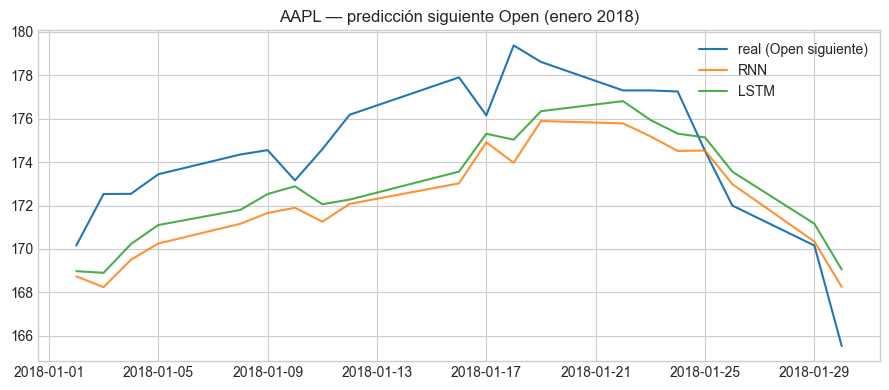

In [6]:
# Comparación en escala original (USD) para interpretación
def inv(x):
    return scaler.inverse_transform(np.asarray(x).reshape(-1, 1)).ravel()


y_ev_true_usd = inv(y_eval)
y_ev_rnn_usd = inv(y_ev_rnn)
y_ev_lstm_usd = inv(y_ev_l)

metrics_report(y_ev_true_usd, y_ev_rnn_usd, "RNN eval (USD)")
metrics_report(y_ev_true_usd, y_ev_lstm_usd, "LSTM eval (USD)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(eval_df["Date"].iloc[: len(y_eval)], y_ev_true_usd, label="real (Open siguiente)")
ax.plot(eval_df["Date"].iloc[: len(y_eval)], y_ev_rnn_usd, label="RNN", alpha=0.85)
ax.plot(eval_df["Date"].iloc[: len(y_eval)], y_ev_lstm_usd, label="LSTM", alpha=0.85)
ax.legend()
ax.set_title("AAPL — predicción siguiente Open (enero 2018)")
plt.tight_layout()
plt.show()


## 6. Resultados

**Datos y ventana.** Tras construir secuencias con `LOOKBACK = 30`, el entrenamiento quedó con **1 229** pares `(30, 1)` → objetivo siguiente día; la evaluación de **enero 2018** generó **20** secuencias (un mes hábil acotado al archivo de evaluación). Escala: `MinMaxScaler` solo sobre `Open` del histórico de entrenamiento; las métricas en “scaled” son útiles para comparar modelos, y las de **USD** interpretan el error en dólares.

**Rendimiento en entrenamiento (ambos modelos).** En la corrida mostrada, RNN y LSTM alcanzan **R² ≈ 0,995** sobre el conjunto de entrenamiento (MAE del orden de **0,012–0,013** y RMSE **~0,017** en escala normalizada). Eso indica que ambas redes **ajustan muy bien** la dinámica reciente del precio dentro del periodo 2013–2017 usado para ajustar el escalador y las pesos.

**Generalización a enero 2018 (lo relevante para la guía).** Aquí aparece la diferencia clara. La **RNN** en evaluación (scaled) baja a **R² ≈ 0,20** (MAE **~0,021**, RMSE **~0,025**), mientras que la **LSTM** mantiene **R² ≈ 0,43** (MAE **~0,018**, RMSE **~0,021**). En **USD**, la LSTM reduce el MAE respecto a la RNN (aprox. **2,15 USD vs 2,56 USD**) y el RMSE (**~2,48 vs ~2,94**). Por tanto, **en este corte temporal la LSTM generaliza mejor** que la RNN apilada con la misma profundidad de capas recurrentes.

**Sobreajuste y lectura del gráfico.** El salto de R² de **~0,995** (train) a **0,2–0,4** (eval) muestra **sobreajuste** a la historia larga y/o que enero 2018 no se comporta exactamente como el train (cambio de régimen, volatilidad). El gráfico de series en enero refleja que **ambas** predicciones siguen la tendencia global con cierto **retraso** respecto al precio real y subestiman movimientos bruscos (p. ej. caídas finales de mes); aun así, la curva **LSTM** se pega más al **Open** siguiente que la **RNN**.

**Conclusión.** Para predecir el siguiente `Open` de AAPL con la arquitectura y datos usados, **LSTM supera a la RNN** en MAE, RMSE y R² en enero 2018. Mejoras posibles (opcionales) serían validación temporal más larga, regularización, distinto `LOOKBACK` o features adicionales; los números exactos pueden variar ligeramente si se vuelve a ejecutar el notebook con otra semilla o versión de TensorFlow.
